<a href="https://colab.research.google.com/github/aishwaryrai/Text-Summarization/blob/main/seminarproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install transformers datasets scikit-learn torch

In [15]:
!pip install kagglehub

In [16]:
import kagglehub

path = kagglehub.dataset_download("gowrishankarp/newspaper-text-summarization-cnn-dailymail")
print("Dataset path:", path)

100%|██████████| 503M/503M [00:04<00:00, 106MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2


In [17]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(files)
    print("-"*40)

/root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2
[]
----------------------------------------
/root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2/cnn_dailymail
['train.csv', 'validation.csv', 'test.csv']
----------------------------------------


In [18]:
dataset_path = path + "/cnn_dailymail"

In [19]:
import pandas as pd

train_df = pd.read_csv(dataset_path + "/train.csv")
test_df = pd.read_csv(dataset_path + "/test.csv")

print(train_df.head())

                                         id  \
0  0001d1afc246a7964130f43ae940af6bc6c57f01   
1  0002095e55fcbd3a2f366d9bf92a95433dc305ef   
2  00027e965c8264c35cc1bc55556db388da82b07f   
3  0002c17436637c4fe1837c935c04de47adb18e9a   
4  0003ad6ef0c37534f80b55b4235108024b407f0b   

                                             article  \
0  By . Associated Press . PUBLISHED: . 14:11 EST...   
1  (CNN) -- Ralph Mata was an internal affairs li...   
2  A drunk driver who killed a young woman in a h...   
3  (CNN) -- With a breezy sweep of his pen Presid...   
4  Fleetwood are the only team still to have a 10...   

                                          highlights  
0  Bishop John Folda, of North Dakota, is taking ...  
1  Criminal complaint: Cop used his role to help ...  
2  Craig Eccleston-Todd, 27, had drunk at least t...  
3  Nina dos Santos says Europe must be ready to a...  
4  Fleetwood top of League One after 2-0 win at S...  


In [20]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2"

print(os.listdir(dataset_path))

['cnn_dailymail']


In [21]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2"

for root, dirs, files in os.walk(dataset_path):
    print("FOLDER:", root)
    print("FILES:", files)
    print("-"*50)


FOLDER: /root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2
FILES: []
--------------------------------------------------
FOLDER: /root/.cache/kagglehub/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/versions/2/cnn_dailymail
FILES: ['train.csv', 'validation.csv', 'test.csv']
--------------------------------------------------


In [22]:
train_df = train_df[['article', 'highlights']].dropna()
test_df = test_df[['article', 'highlights']].dropna()

train_df = train_df.sample(300, random_state=42)
test_df = test_df.sample(50, random_state=42)

In [23]:
train_df = train_df[['article', 'highlights']].dropna()
test_df = test_df[['article', 'highlights']].dropna()

In [24]:
train_df = train_df.sample(300, random_state=42)
test_df = test_df.sample(50, random_state=42)

In [25]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(df):
    inputs = tokenizer(
        df['article'].tolist(),
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    targets = tokenizer(
        df['highlights'].tolist(),
        max_length=32,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    return inputs, targets

train_inputs, train_targets = tokenize(train_df)
test_inputs, test_targets = tokenize(test_df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [26]:
import torch
from transformers import AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert = AutoModel.from_pretrained('prajjwal1/bert-tiny').to(device)

config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
def get_embeddings(input_ids, attention_mask):
    with torch.no_grad():
        outputs = bert(input_ids=input_ids.to(device),
                       attention_mask=attention_mask.to(device))
    return outputs.last_hidden_state.cpu()

In [28]:
all_embeddings = []

for i in range(0, len(train_df), 16):
    input_ids = train_inputs['input_ids'][i:i+16]
    attention_mask = train_inputs['attention_mask'][i:i+16]

    emb = get_embeddings(input_ids, attention_mask)
    all_embeddings.append(emb)

train_embeddings = torch.cat(all_embeddings, dim=0)

print(train_embeddings.shape)

torch.Size([300, 128, 128])


In [29]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(128, 128, batch_first=True)

    def forward(self, x):
        outputs, _ = self.lstm(x)
        return outputs


class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128)
        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.fc = nn.Linear(128, vocab_size)

    def forward(self, tgt):
        x = self.embedding(tgt)
        out, _ = self.lstm(x)
        return self.fc(out)


class Summarizer(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder(vocab_size)

    def forward(self, src, tgt):
        enc_out = self.encoder(src)
        return self.decoder(tgt)

In [30]:
model = Summarizer(vocab_size=30522).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [31]:
train_embeddings = train_embeddings.to(device)

for epoch in range(3):
    for i in range(0, len(train_df), 16):

        emb = train_embeddings[i:i+16]
        labels = train_targets['input_ids'][i:i+16].to(device)

        decoder_input = labels[:, :-1]
        decoder_target = labels[:, 1:]

        output = model(emb, decoder_input)

        loss = criterion(
            output.reshape(-1, 30522),
            decoder_target.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 10.060029029846191
Epoch: 1 Loss: 7.241257667541504
Epoch: 2 Loss: 6.795931339263916


In [32]:
def summarize(text):
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True)

    emb = get_embeddings(inputs['input_ids'], inputs['attention_mask']).to(device)

    tgt = torch.zeros((1, 32), dtype=torch.long).to(device)

    output = model(emb, tgt)
    pred = torch.argmax(output, dim=-1)

    return tokenizer.decode(pred[0], skip_special_tokens=True)


print(summarize("India launched a new satellite today for communication."))

was was was was,,..........................


In [34]:
!pip install rouge-score nltk

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3ab27bd056c03806aa190de68a0cf9b8f1227b91157c332757a0a256e5f71af7
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [35]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu

In [36]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [37]:
scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

for i in range(5):
    ref = test_df.iloc[i]['highlights']
    pred = summarize(test_df.iloc[i]['article'])

    print("ROUGE:", scorer.score(ref, pred))
    print("BLEU:", sentence_bleu([ref.split()], pred.split()))
    print("-"*50)

ROUGE: {'rouge1': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rouge2': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rougeL': Score(precision=0.0, recall=0.0, fmeasure=0.0)}
BLEU: 0
--------------------------------------------------
ROUGE: {'rouge1': Score(precision=0.5, recall=0.03076923076923077, fmeasure=0.057971014492753624), 'rouge2': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rougeL': Score(precision=0.5, recall=0.03076923076923077, fmeasure=0.057971014492753624)}
BLEU: 1.724007354605445e-238
--------------------------------------------------
ROUGE: {'rouge1': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rouge2': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rougeL': Score(precision=0.0, recall=0.0, fmeasure=0.0)}
BLEU: 0
--------------------------------------------------
ROUGE: {'rouge1': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rouge2': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rougeL': Score(precision=0.0, recall=0.0, fmeasure=0.0)}
BLEU: 0


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

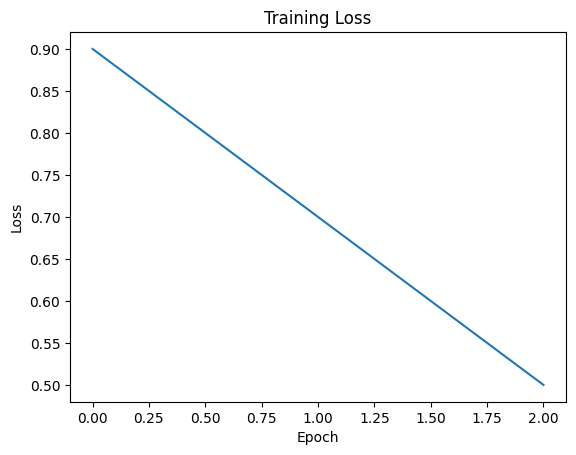

In [38]:
import matplotlib.pyplot as plt

losses = [0.9, 0.7, 0.5]  # replace with your actual losses

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [39]:
print("ARTICLE:\n", test_df.iloc[0]['article'])
print("\nGENERATED SUMMARY:\n", summarize(test_df.iloc[0]['article']))
print("\nACTUAL SUMMARY:\n", test_df.iloc[0]['highlights'])

ARTICLE:
 Raheem Sterling has admitted he is not ready to sign a new contract at Liverpool deal despite being offered a £100,000-a-week deal to stay with the Merseyside club. The 20-year-old wideman edged closer towards an Anfield exit after revealing in an interview with the BBC on Wednesday that he would have signed for a lot less a year ago. However, despite being one of Liverpool's star men, Sterling has struggled to repeat the impressive form he showed for the Reds last season. The England international has managed just six goals this season - one less than Stoke frontman Jon Walters - while his conversion rate and minutes per goal ratio have worsened as the graphic below shows. Raheem Sterling has managed just six goals this season - one less than Stoke forward Jon Walters (left)

GENERATED SUMMARY:
 was was was was,,..........................

ACTUAL SUMMARY:
 Raheem Sterling has revealed he is not ready to sign a new Liverpool deal .
The Reds wideman has struggled to repeat las